# Reaction networks

## General reactions

Consider the general reaction, 

$$X + a \rightarrow Y + b$$

where $X$ and $Y$ are typically nuclei and $a$ and $b$ are light particles (like $p$, $\alpha$, $n$)

We normally write this in a compact form as $X(a, b)Y$.

### Nuclear properties

We characterize a nucleus with a mass number, $A$ (the number of protons and neutrons) and a proton number, $Z$.

In nuclear 
physics, masses are measured as the atomic mass excess:

$$\Delta M_{AZ} = (m_{AZ} - A m_u) c^2$$

where $m_{AZ}$ is the actual mass and $m_u$ is the atomic mass unit.

### Energy release

The energy release (or $Q$) value is just the difference in masses.

In any reaction, the number of baryons is conserved, so the $Q$ value is the difference in mass excesses.  For our reaction, it is:

$$Q = (\Delta M_a + \Delta M_X) - (\Delta M_b - \Delta M_Y)$$

### Reaction rate

Imagine an experiment:

* A beam of partial $a$ is shot at a fixed target of $X$
* Each $X$ nuclei presents a cross-section for reactions $\sigma$
* The number of reactions will depend on the amount of $X$ in the target
* The number of reactions / second will also depend on the flux of $a$

General form of a rate:

$$r = (n_a v) (n_X \sigma)$$

```{note}
$r$ has units of # of reactions / volume / time
```

Notice:

* v is the relative velocity between $X$ and $a$
* $\sigma$ will be energy dependent, $\sigma(v)$
* If $X$ and $a$ are the same particle, we divide by two (only care about pairs, not ordering)

$$r = \frac{n_a n_X \sigma(v) v}{1 + \delta_{Xa}}$$

There's a range of velocities

* If both $X$ and $a$ velocities follow the Maxwell-Boltzmann distribution,
  then the relative   velocity does too.
* Define $\phi(v)$ as M-B distribution (normalized to integrate to 1)
* Velocity averaged reaction rate is:

  $$r = \frac{n_a n_X}{1 + \delta_{aX}} \int_0^\infty v \sigma(v) \phi(v) dv \equiv \frac{n_a n_X}{1+ \delta_{aX}} \langle \sigma v \rangle$$

Note, all of the nuclear physics is contained in $\sigma$.

The quantity $\sigma v$ depends only on temperature.

The evolution of nucleus $X$ is given as:

$$\frac{dn_X}{dt} = -r = -n_a n_X \langle \sigma v \rangle$$

where the $-$  indicates that $X$ is being destroyed.


## Mass and molar fractions

We define the mass fraction of species $k$ as:

$$X_k = \frac{\rho_k}{\rho}$$

where $\rho_k$ is the mass density of species $k$.  Note that by conservation of mass,

$$\sum_k X_k = 1$$

We can express the mass density of species $k$ as:

$$\rho_k = A_k m_u n_k$$

where $A_k m_u$ represents the mass of a single nucleus.  This then shows that

$$n_k = \frac{\rho_k}{A_k m_u} = \frac{\rho X_k}{A_k m_u}$$

We define the molar fraction of species $k$ as:

$$Y_k = \frac{X_k}{A_k}$$

then we have:

$$n_k = \frac{\rho Y_k}{m_u}$$

it is common to take $N_A = 1/m_u$ (in CGS), and write this as:

$$n_k = \rho N_A Y_k$$

With this definition, our evolution equation becomes:

$$\frac{dY(X)}{dt} = -\rho Y(a) Y(X) N_A \langle \sigma v \rangle$$

Reaction rate libraries typically provide $N_A \langle \sigma v \rangle$.

## O-burning

Oxygen burning primarily takes place via:

$$\begin{split}{}^{16}\mathrm{O} + {}^{16}\mathrm{O} \rightarrow \begin{cases}
       {}^{28}\mathrm{Si} + \alpha \\
       {}^{31}\mathrm{P} + p \\
       {}^{31}\mathrm{S} + n \end{cases}
\end{split}$$

In [8]:
import pynucastro as pyna

In [9]:
rl = pyna.ReacLibLibrary()
rates = rl.get_rate_by_name(["o16(o16,a)si28",
                             "o16(o16,p)p31",
                             "o16(o16,n)s31"])

In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
r.pretty_string

'${}^{16}\\mathrm{O} + {}^{16}\\mathrm{O} \\rightarrow {}^{4}\\mathrm{He} + {}^{28}\\mathrm{Si}$'

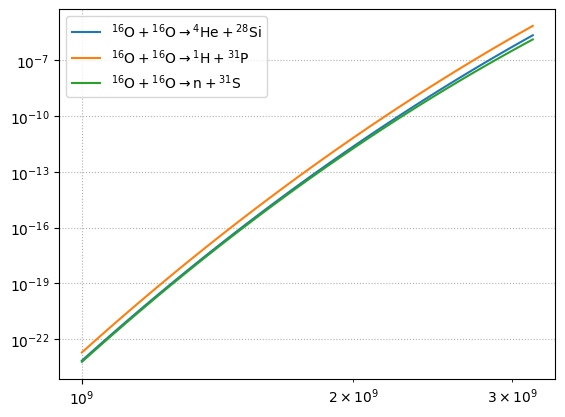

In [30]:
fig, ax = plt.subplots()
Ts = np.logspace(9, 9.5, 100)

for r in rates:
    ax.loglog(Ts, [r.eval(T) for T in Ts], label=f"{r.pretty_string}")

ax.grid(ls=":")
ax.legend()

Notice that the branching that emits a neutron is the slowest.  It is also the least energetic

In [29]:
for r in rates:
    print(f"{r!s:30} : {r.Q} MeV")

O16 + O16 ⟶ He4 + Si28         : 9.593 MeV
O16 + O16 ⟶ p + P31            : 7.678 MeV
O16 + O16 ⟶ n + S31            : 1.5 MeV


for this reason, it is often neglected.

We can also check the temperature sensitivity, by expressing the rate as:

$$r = r_0 \left ( \frac{T}{T_0} \right )^\nu$$

exploring various $T_0$, we find:

In [33]:
for T0 in [5.e8, 1.e9, 2.e9, 4.e9]:
    nu = rates[0].get_rate_exponent(T0)
    print(f"{T0:6.2g} : {nu:5.2f}")

 5e+08 : 55.96
 1e+09 : 43.64
 2e+09 : 33.24
 4e+09 : 23.75


This is extremely temperature sensitive.

## Electron-capture / $\beta$-decay

## Sources for rates

## Integration methods

## One-zone burn